<a href="https://colab.research.google.com/github/ealger22/main/blob/CSC-302-Data-Visualization/ICA11_Flights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Rows: 144 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): month
dbl (2): year, passengers

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


year,month,passengers
<dbl>,<chr>,<dbl>
1949,Jan,112
1949,Feb,118
1949,Mar,132
1949,Apr,129
1949,May,121
1949,Jun,135


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


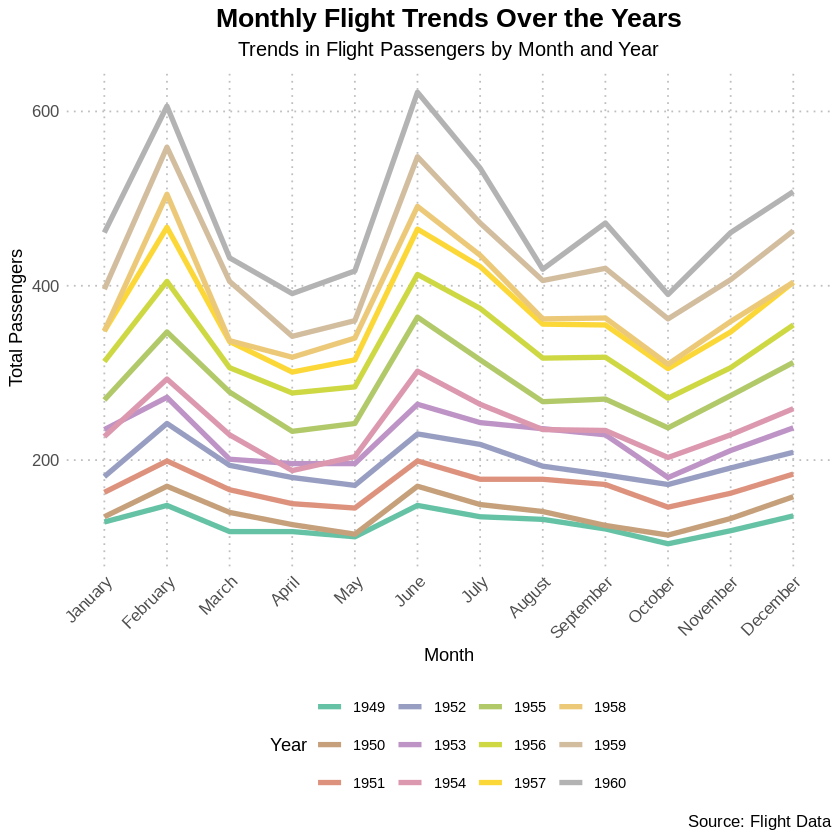

In [21]:
# Load necessary libraries
library(dplyr)
library(ggplot2)
library(RColorBrewer)

# Load the flights dataset from CSV
flights_data <- read_csv("/content/drive/MyDrive/ColabFiles/flights.csv")

# Inspect the first few rows of the dataset
head(flights_data)

# Step 1: Group the data by 'month' and 'year' to calculate the total passengers per month
monthly_data <- flights_data %>%
  group_by(year, month) %>%
  summarise(TotalFlights = sum(passengers, na.rm = TRUE)) %>%
  ungroup()  # To remove the grouping after summarizing

# Step 2: Generate the line plot for monthly total flights with improved aesthetics
# Use a larger palette to handle more than 8 years
num_years <- length(unique(monthly_data$year))
colors <- colorRampPalette(brewer.pal(8, "Set2"))(num_years)  # Create a custom palette if there are more than 8 years

ggplot(monthly_data, aes(x = month, y = TotalFlights, color = factor(year), group = year)) +
  geom_line(linewidth = 1.5) +  # Make the lines thicker for better visibility
  scale_x_discrete(labels = month.name, name = "Month") +  # Correctly display month names
  scale_y_continuous(name = "Total Passengers", labels = scales::comma) +  # Format y-axis with commas
  labs(
    title = "Monthly Flight Trends Over the Years",
    subtitle = "Trends in Flight Passengers by Month and Year",
    caption = "Source: Flight Data",
    color = "Year"
  ) +
  theme_minimal() +  # Use a clean and minimal theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10),  # Rotate x-axis labels for better readability
    axis.text.y = element_text(size = 10),  # Set y-axis text size
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),  # Title styling
    plot.subtitle = element_text(size = 12, hjust = 0.5),  # Subtitle styling
    plot.caption = element_text(size = 10, hjust = 1),  # Caption styling
    legend.position = "bottom",  # Place legend at the bottom for better spacing
    panel.grid.major = element_line(color = "gray", size = 0.5, linetype = "dotted"),  # Add dotted grid lines for readability
    panel.grid.minor = element_blank()  # Remove minor grid lines for clarity
  ) +
  scale_color_manual(values = colors)  # Use the adjusted color palette


In [23]:
# Install and load necessary libraries
install.packages("readxl")  # If not already installed
library(readxl)

# Load the flights dataset from the Excel file
flights_data <- read_excel("/content/drive/MyDrive/ColabFiles/flights.xlsx")  # Adjust the path as needed

# Inspect the first few rows of the dataset
head(flights_data)

# Continue with the rest of your analysis or plotting...


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



year,month,passengers
<dbl>,<chr>,<dbl>
1960,Jan,417
1960,Feb,391
1960,Mar,419
1960,Apr,461
1960,May,472
1960,Jun,535


In [24]:
# Install and load necessary libraries
install.packages("readxl")  # Install if not already installed
install.packages("tidyverse")  # Install if not already installed
library(readxl)
library(tidyverse)  # This includes tidyr and dplyr

# Load the flights dataset from the Excel file
flights_data <- read_excel("/content/drive/MyDrive/ColabFiles/flights.xlsx")  # Adjust the path as needed

# Inspect the first few rows of the dataset
head(flights_data)

# Step 1: Pivot the data to a wide format for analysis
# Pivot data such that each year becomes a column for the passengers count across months
flights_pivot <- flights_data %>%
  pivot_wider(
    names_from = year,  # Create a column for each year
    values_from = passengers,  # Populate with the number of passengers
    values_fill = list(passengers = 0)  # Fill missing values with 0
  )

# Inspect the pivoted data
head(flights_pivot)

# Continue with any further analysis or visualization...


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ purrr   1.0.4     ✔ tibble  3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


year,month,passengers
<dbl>,<chr>,<dbl>
1960,Jan,417
1960,Feb,391
1960,Mar,419
1960,Apr,461
1960,May,472
1960,Jun,535


month,1960,1959,1958,1957,1956,1955,1954,1953,1952,1951,1950,1949
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Jan,417,360,340,315,284,242,204,196,171,145,115,112
Feb,391,342,318,301,277,233,188,196,180,150,126,118
Mar,419,406,362,356,317,267,235,236,193,178,141,132
Apr,461,396,348,348,313,269,227,235,181,163,135,129
May,472,420,363,355,318,270,234,229,183,172,125,121
Jun,535,472,435,422,374,315,264,243,218,178,149,135


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


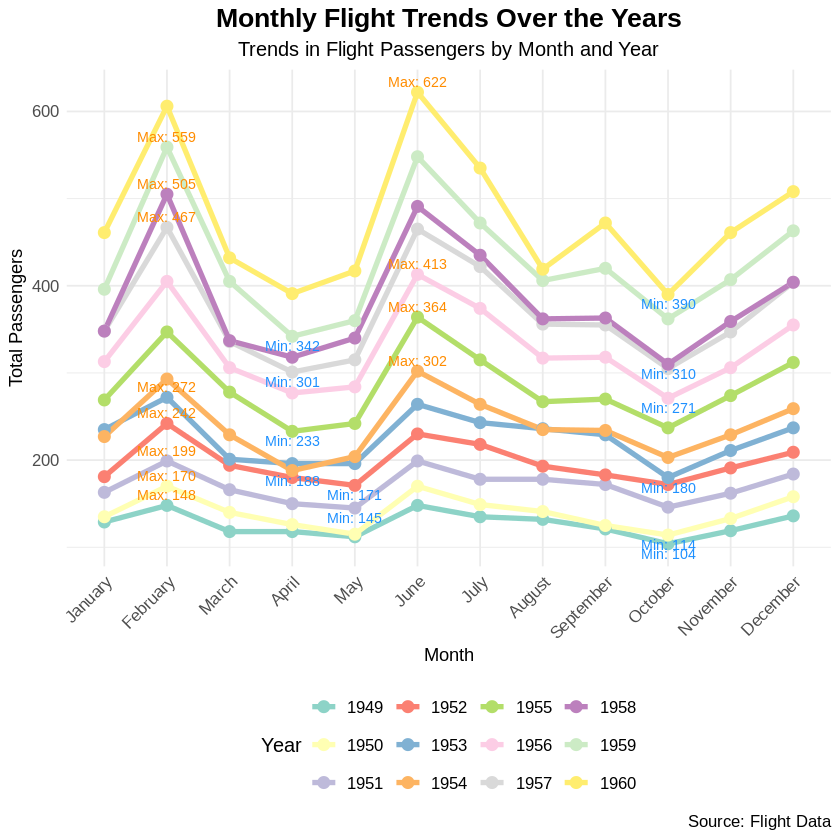

In [56]:
# Load necessary libraries
library(dplyr)
library(ggplot2)
library(readxl)
library(RColorBrewer)

# Load the flight data from the correct sheet
flights_data <- read_excel("/content/drive/MyDrive/ColabFiles/flight_data.xlsx", sheet = "flights")

# Step 1: Group data by month and year for summarizing passengers
monthly_data <- flights_data %>%
  group_by(year, month) %>%
  summarise(TotalFlights = sum(passengers, na.rm = TRUE)) %>%
  ungroup()

# Step 2: Calculate highs and lows for each year and month
highs_lows <- monthly_data %>%
  group_by(year) %>%
  summarise(
    max_passengers = max(TotalFlights),
    min_passengers = min(TotalFlights),
    max_month = month[which.max(TotalFlights)],
    min_month = month[which.min(TotalFlights)]
  )

# Step 3: Generate the line plot for monthly total flights
ggplot(monthly_data, aes(x = month, y = TotalFlights, color = factor(year), group = year)) +
  geom_line(linewidth = 1.5) +  # Line width for better visibility
  geom_point(size = 3) +  # Add points for better visualization
  geom_text(data = highs_lows, aes(x = max_month, y = max_passengers, label = paste("Max:", max_passengers)),
            color = "darkorange", vjust = -0.5, size = 3) +  # Label for max point with darkorange color
  geom_text(data = highs_lows, aes(x = min_month, y = min_passengers, label = paste("Min:", min_passengers)),
            color = "dodgerblue", vjust = 1.5, size = 3) +  # Label for min point with dodgerblue color
  scale_x_discrete(labels = month.name, name = "Month") +  # Display month names
  scale_y_continuous(name = "Total Passengers", labels = scales::comma) +  # Format y-axis with commas
  labs(
    title = "Monthly Flight Trends Over the Years",
    subtitle = "Trends in Flight Passengers by Month and Year",
    caption = "Source: Flight Data",
    color = "Year"
  ) +
  theme_minimal() +  # Minimalist theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10),  # Rotate x-axis labels
    axis.text.y = element_text(size = 10),  # Y-axis text size
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),  # Title styling
    plot.subtitle = element_text(size = 12, hjust = 0.5),  # Subtitle styling
    plot.caption = element_text(size = 10, hjust = 1),  # Caption styling
    legend.position = "bottom",  # Place legend at the bottom for better spacing
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  ) +
  scale_color_brewer(palette = "Set3")  # Use Set3 palette for more colors

# Comments section
# In this code:
# - Libraries used: dplyr for data manipulation, ggplot2 for visualization,
#   readxl for reading Excel files, and RColorBrewer for color palettes.
# - The data is first grouped by year and month to calculate the total number of passengers per month.
# - We calculate the maximum and minimum values for passengers and annotate the plot with these values.
# - The colors for the min and max values are updated to 'darkorange' and 'dodgerblue' respectively,
#   making the text more readable.
# - A line plot is generated to visualize the trends in total passengers by month and year.
# - The color palette 'Set3' from RColorBrewer is used to differentiate the years.
